# Задача сегментации с использованием U-Net

In [2]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
import glob
import tensorflow as tf
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.layers import Flatten, Dense, Reshape
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [37]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vpapenko/nails-segmentation")

print("Path to dataset files:", path)

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/albertzagibin/.cache/kagglehub/datasets/vpapenko/nails-segmentation/versions/1


## Функции для отображения результатов

In [4]:
def plot_image_and_mask(images, masks, image_paths):
    plt.figure(figsize=(20, 6))

    for i in range(5):
        idx = np.random.randint(len(images))
        plt.subplot(3, 8, i + 1)
        plt.imshow(images[idx], cmap="gray")
        plt.axis("off")
        plt.title(image_paths[idx].split("/")[-1])

        plt.subplot(3, 8, i + 9)
        plt.imshow(masks[idx], cmap="gray")
        plt.axis("off")
        plt.title("Mask")

    plt.show()


In [5]:
def plot_predictions(X_test, y_test, preds):
    plt.figure(figsize=(20, 6))

    for i in range(6):
        idx = np.random.randint(len(preds))
        plt.subplot(3, 8, i + 1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Image")

        plt.subplot(3, 8, i + 9)
        plt.imshow(y_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Original Mask")

        plt.subplot(3, 8, i + 17)
        plt.imshow(preds[idx], cmap="gray")
        plt.axis("off")
        plt.title("Predicted Mask")

    plt.show()

In [6]:
def plot_training_history(history, title="Training History"):
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    n_metrics = len(metrics)
    
    n_cols = 2
    n_rows = (n_metrics + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten() 
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric], label=f"train {metric}")

        val_metric = f"val_{metric}"
        if val_metric in history.history:
            ax.plot(history.history[val_metric], label=f"val {metric}")
        
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"Training vs Validation {metric.capitalize()}")
        ax.legend()
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Подготовка данных

In [7]:
folders = os.listdir(path)
folders

['.DS_Store',
 'images',
 'nails_segmentation',
 'labels',
 'nails_segmentation.zip']

In [8]:
image_paths = glob.glob(path+'/images/*')
mask_paths = glob.glob(path+'/labels/*')

In [9]:
def load_image(path, color_mode=None):
    img = None
    if color_mode:
        img = load_img(path, target_size=(128, 128), color_mode=color_mode)
    else:
        img = load_img(path, target_size=(128, 128))
    
    image_array = img_to_array(img)
    image_array /= 255.
    return image_array

In [10]:
images = []
masks = []

for image_path, mask_path in tqdm(zip(image_paths, mask_paths)):
    image = load_image(image_path)
    images.append(image)

    mask = load_image(mask_path, color_mode='grayscale')
    masks.append(mask)

52it [00:00, 134.77it/s]


In [11]:
images = np.array(images)
masks = np.array(masks)

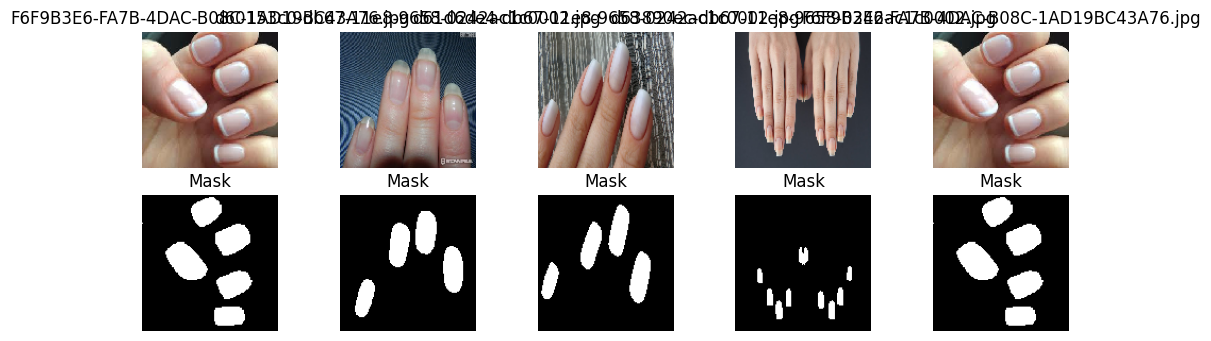

In [12]:
plot_image_and_mask(images, masks, image_paths)

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train set: {X_train.shape}, {y_train.shape}")

Train set: (41, 128, 128, 3), (41, 128, 128, 1)


## Baseline - Полносвязанная нейронная сеть

In [16]:
input_shape = (128, 128, 3)
output_shape = (128, 128, 1)

sequential_model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(np.prod(output_shape), activation='sigmoid'),
    Reshape(output_shape)
])

sequential_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', Precision(), Recall()]
)
# sequential_model.summary()

In [17]:
sequential_history = sequential_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.5229 - loss: 0.6866 - precision_1: 0.0548 - recall_1: 0.4855 - val_accuracy: 0.7504 - val_loss: 0.5208 - val_precision_1: 0.0257 - val_recall_1: 0.2283
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7624 - loss: 0.5084 - precision_1: 0.0552 - recall_1: 0.2124 - val_accuracy: 0.9383 - val_loss: 0.2310 - val_precision_1: 0.0300 - val_recall_1: 0.0425
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9188 - loss: 0.2995 - precision_1: 0.0546 - recall_1: 0.0314 - val_accuracy: 0.9711 - val_loss: 0.1733 - val_precision_1: 0.0143 - val_recall_1: 0.0014
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9440 - loss: 0.2276 - precision_1: 0.1066 - recall_1: 0.0059 - val_accuracy: 0.9718 - val_loss: 0.1774 - val_precision_1: 0.0068 - val_recall_1: 4.6211e-04
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9452 - loss: 0.2066 - precision_1: 0.1975 - recall_1: 0.0069 - val_

## Реализация U-Net

In [18]:
def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    return x


In [19]:
def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


In [20]:
def decoder_block(inputs, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
    x = layers.concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [21]:
def build_unet(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # --- Bottleneck ---
    b1 = conv_block(p4, 1024)

    # --- Decoder ---
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # --- Output ---
    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(d4)

    model = models.Model(inputs, outputs, name="U-Net")

    return model

In [23]:
unet_model = build_unet(input_shape=(128, 128, 3), num_classes=1)
unet_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', Precision(), Recall()]
)
# unet_model.summary()

In [24]:
unet_history = unet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5610 - loss: 0.6183 - precision_3: 0.0444 - recall_3: 0.3500 - val_accuracy: 0.9736 - val_loss: 13.0903 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 22.5419 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00 - val_accuracy: 0.9736 - val_loss: 0.2654 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 0.3483 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00 - val_accuracy: 0.9736 - val_loss: 0.3019 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 0.3696 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00 - val_accuracy: 0.9736 - val_loss: 0.3052 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9464 - loss: 0.3706 - precis

## Сравнение результатов

### Baseline

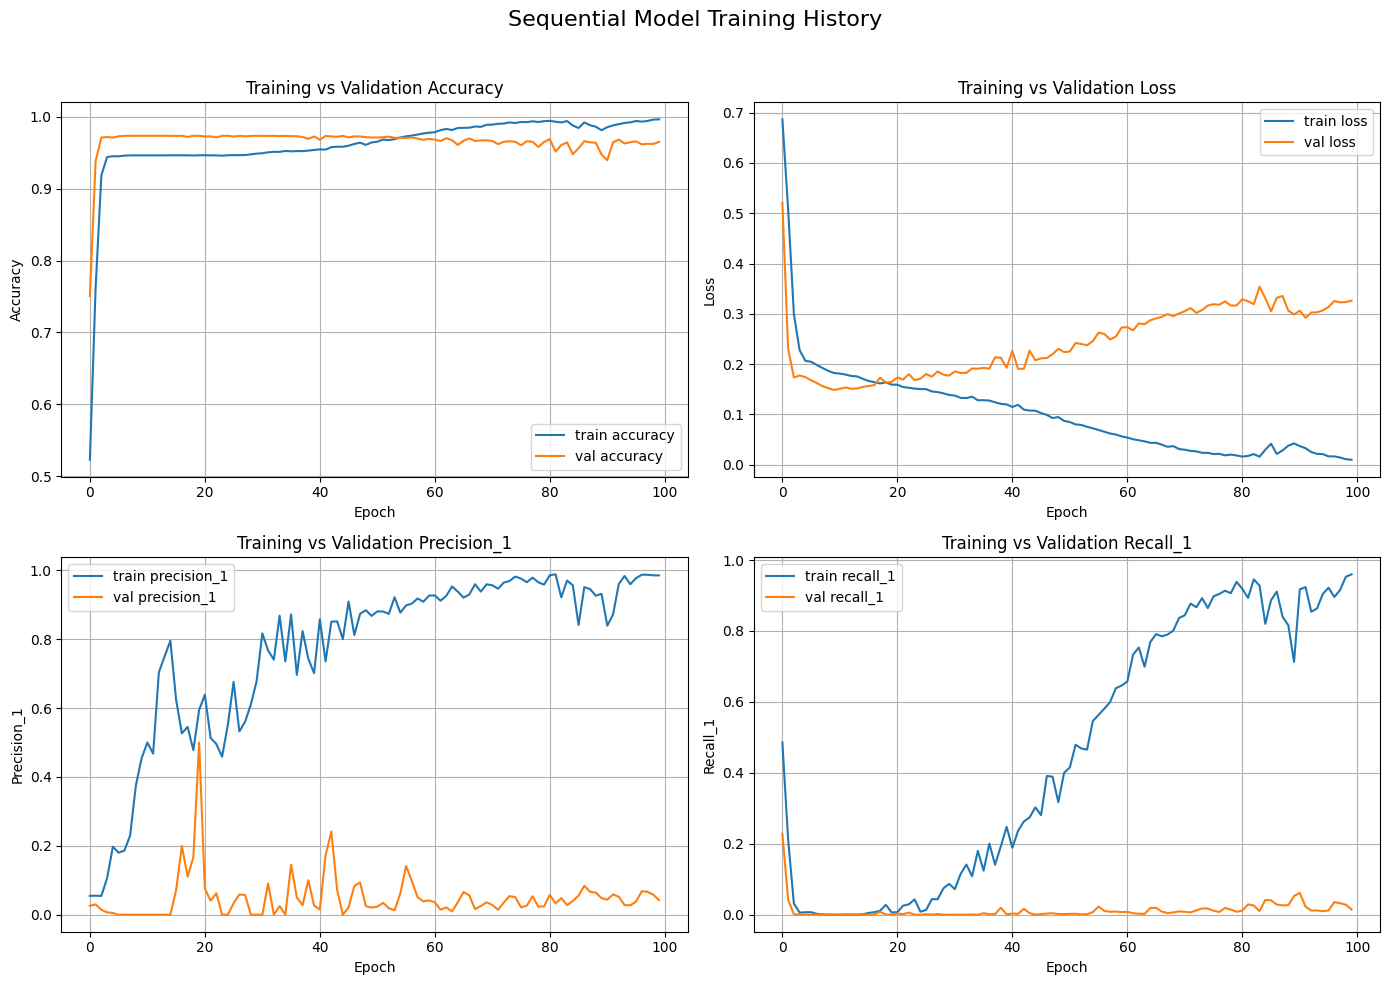

In [25]:
plot_training_history(sequential_history, title = "Sequential Model Training History")

In [26]:
seq_y_pred = sequential_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


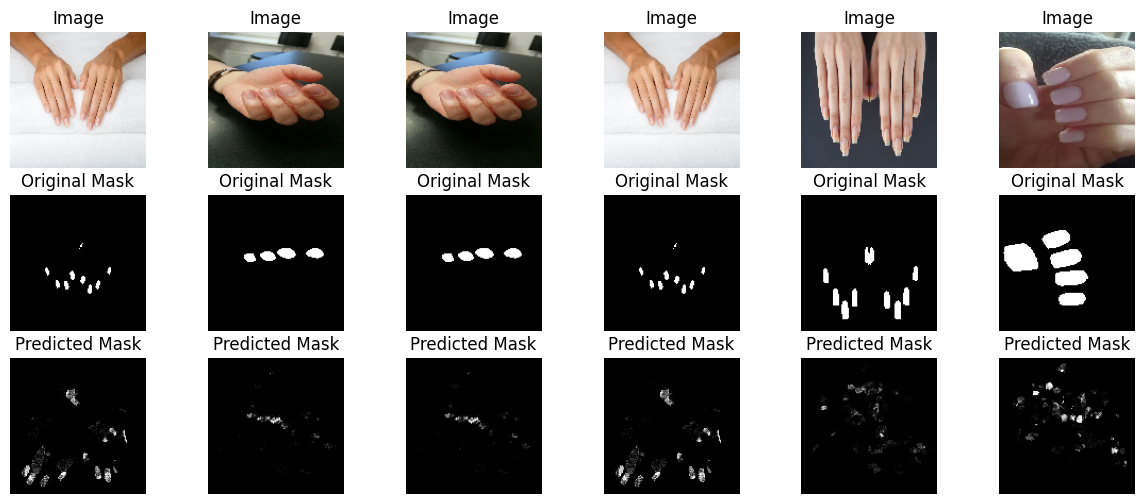

In [27]:
plot_predictions(X_test, y_test, seq_y_pred)

In [28]:
seq_results = sequential_model.evaluate(X_test, y_test, verbose=0)
metrics_names = sequential_model.metrics_names
for name, value in zip(metrics_names, seq_results):
    print(f"{name}: {value:.4f}")

loss: 0.4415
compile_metrics: 0.9444


### U-Net

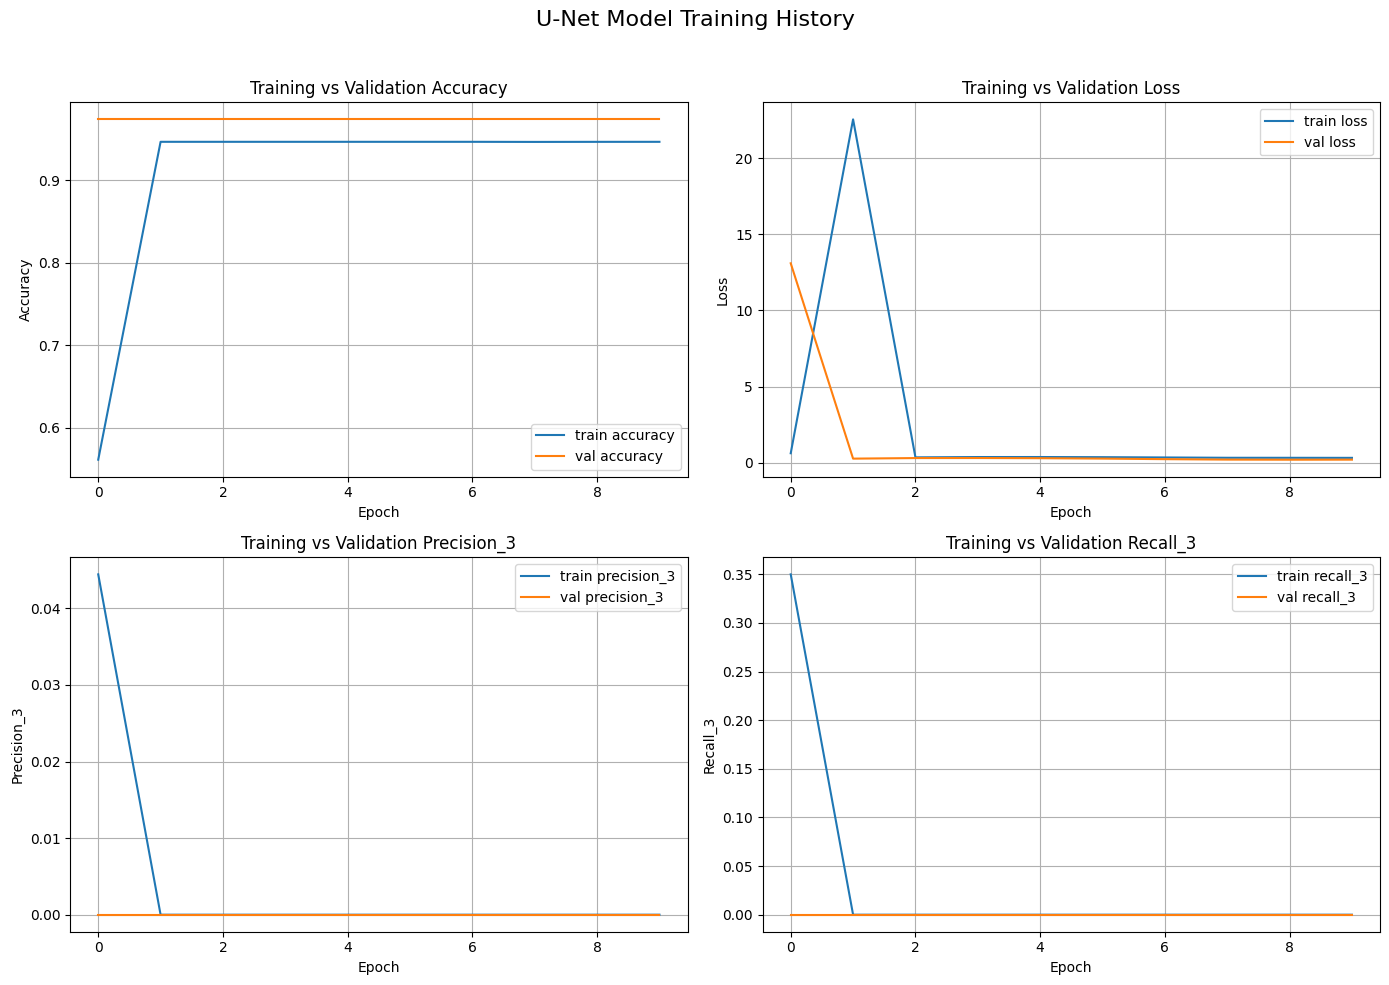

In [29]:
plot_training_history(unet_history, title = "U-Net Model Training History")

In [30]:
unet_y_pred = unet_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step


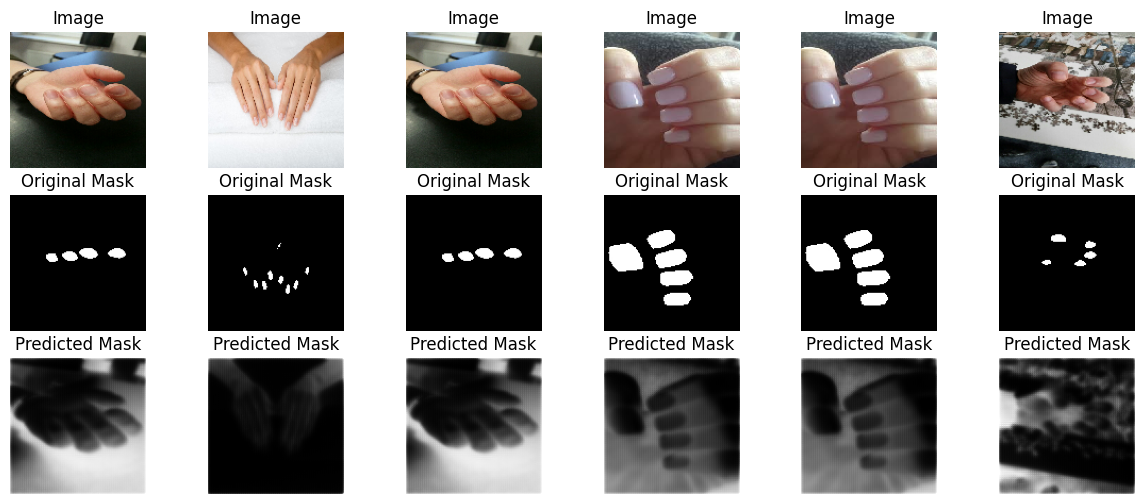

In [31]:
plot_predictions(X_test, y_test, unet_y_pred)

In [32]:
unet_results = unet_model.evaluate(X_test, y_test, verbose=0)
metrics_names = unet_model.metrics_names
for name, value in zip(metrics_names, unet_results):
    print(f"{name}: {value:.4f}")

loss: 0.2639
compile_metrics: 0.9594


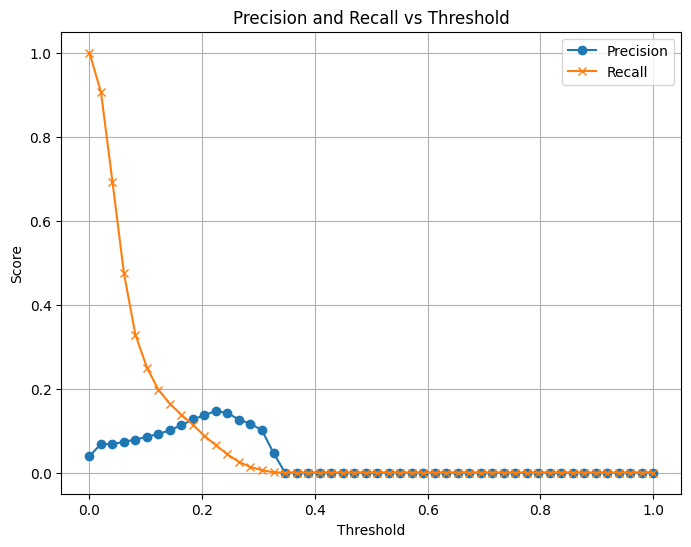

In [29]:
thresholds = np.linspace(0, 1, 50) 
precision_list = []
recall_list = []

y_test_flat = y_test.flatten().astype(int)

for t in thresholds:
    y_pred_bin = (unet_y_pred > t).astype(int)
    y_pred_flat = y_pred_bin.flatten()
    
    precision_list.append(precision_score(y_test_flat, y_pred_flat, zero_division=0))
    recall_list.append(recall_score(y_test_flat, y_pred_flat, zero_division=0))

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision_list, label='Precision', marker='o')
plt.plot(thresholds, recall_list, label='Recall', marker='x')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.grid(True)
plt.legend()
plt.show()
